In [1]:
from pathlib import Path

# path saat ini
CURRENT_PATH = Path().resolve()
ROOT = CURRENT_PATH.parent
OUTS = ROOT / "outputs"

In [2]:
import torch, pprint
from pathlib import Path


PT_PATH = OUTS / "final_retrain_lr0.0002_r4" / "final_model.pt"  
ckpt = torch.load(PT_PATH, map_location="cpu")

print("Top-level keys:", ckpt.keys())
cfg = ckpt.get("config", {})
print("\nCONFIG:")
pprint.pprint(cfg)

state = ckpt.get("model_state", None)
if state is None:
    state = ckpt.get("state_dict", None)
print("\nState dict keys sample:", list(state.keys())[:10])
print("Total params in state_dict:", len(state))


Top-level keys: dict_keys(['model_state', 'config'])

CONFIG:
{'batch_size': 52,
 'epochs': 20,
 'grad_accum_steps': 1,
 'lr': 0.0002,
 'model_name': 'microsoft/wavlm-base-plus',
 'r': 4,
 'seed': 42,
 'split': 'strict',
 'use_amp': True}

State dict keys sample: ['backbone.base_model.model.masked_spec_embed', 'backbone.base_model.model.feature_extractor.conv_layers.0.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.0.layer_norm.weight', 'backbone.base_model.model.feature_extractor.conv_layers.0.layer_norm.bias', 'backbone.base_model.model.feature_extractor.conv_layers.1.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.2.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.3.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.4.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.5.conv.weight', 'backbone.base_model.model.feature_extractor.conv_layers.6.conv.weight']
Total params in state

In [3]:
import torch
import torch.nn as nn
from transformers import WavLMModel, AutoFeatureExtractor
from peft import LoraConfig, get_peft_model

class WavLMWithHead(nn.Module):
    def __init__(self, backbone_name: str, r: int, lora_alpha: int = 32, lora_dropout: float = 0.05):
        super().__init__()
        base = WavLMModel.from_pretrained(backbone_name)

        for p in base.parameters():
            p.requires_grad = False

        lora_cfg = LoraConfig(
            r=r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_proj", "v_proj"],
            bias="none",
        )
        self.backbone = get_peft_model(base, lora_cfg)

        hidden = base.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 5),
            nn.Sigmoid(),
        )

    def mean_pool(self, x, attn_mask=None):
        if attn_mask is None:
            return x.mean(dim=1)
        m = attn_mask.unsqueeze(-1).type_as(x)
        return (x * m).sum(dim=1) / (m.sum(dim=1).clamp(min=1.0))

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask)
        h = out.last_hidden_state

        feat_mask = None
        if attention_mask is not None:
            base = self.backbone.base_model if hasattr(self.backbone, "base_model") else self.backbone
            if hasattr(base, "_get_feature_vector_attention_mask"):
                feat_mask = base._get_feature_vector_attention_mask(h.shape[1], attention_mask)

        pooled = self.mean_pool(h, feat_mask)
        return self.head(pooled)


e:\tugas-akhir-qiqi\venv_infer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(PT_PATH, map_location="cpu")
cfg = ckpt.get("config", {})
MODEL_NAME = cfg.get("model_name", "microsoft/wavlm-base-plus")
R = int(cfg.get("r", 8))

model = WavLMWithHead(MODEL_NAME, r=R).to(DEVICE)
model.load_state_dict(ckpt["model_state"], strict=True)
model.eval()

feat = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
print("Loaded OK | model:", MODEL_NAME, "| r:", R)


Loaded OK | model: microsoft/wavlm-base-plus | r: 4


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
import soundfile as sf
import librosa
import torch
from tqdm.auto import tqdm

SR_TARGET = 16000
MAX_SEC = 15.0
MAX_LEN = int(SR_TARGET * MAX_SEC)

def load_wav_trim_only(path: str):
    """Load wav -> mono -> resample -> trim only (no pad). Return None if bad file."""
    try:
        wav, sr = sf.read(path)
    except Exception as e:
        # kalau ada file rusak, skip aja biar proses lanjut
        tqdm.write(f"[WARN] Failed read: {path} | {repr(e)}")
        return None

    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav = wav.astype(np.float32)

    if sr != SR_TARGET:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SR_TARGET)

    if len(wav) > MAX_LEN:
        wav = wav[:MAX_LEN]

    return wav

@torch.no_grad()
def predict_paths(paths, bs=8):
    preds = []
    n_ok = 0

    pbar = tqdm(range(0, len(paths), bs), desc="Infer batches", unit="batch")
    for i in pbar:
        # load audio with progress (per batch)
        batch = []
        for p in paths[i:i+bs]:
            w = load_wav_trim_only(p)
            if w is not None:
                batch.append(w)

        if not batch:
            continue

        n_ok += len(batch)

        inputs = feat(batch, sampling_rate=SR_TARGET, return_tensors="pt", padding=True)
        iv = inputs["input_values"].to(DEVICE)

        am = inputs.get("attention_mask", None)
        if am is not None:
            am = am.to(DEVICE).bool()   # biar mask type konsisten

        yhat = model(iv, am).detach().cpu().numpy()
        preds.append(yhat)

        pbar.set_postfix({"loaded_ok": n_ok})

    if not preds:
        raise RuntimeError("No audio loaded successfully. Check paths / audio files.")

    tqdm.write(f"Loaded OK: {n_ok}/{len(paths)} audios")
    return np.concatenate(preds, axis=0)

# ====== LOAD MANIFEST
MANIFEST = ROOT.parent.parent / "output" / "split_strict" / "manifest_strict.csv"
df = pd.read_csv(MANIFEST)

BASE = ROOT.parent.parent

# sample 100 from val
df_va = df[df["split_strict"]=="val"].sample(100, random_state=42).copy()
df_va["audio_path_abs"] = df_va["audio_out"].apply(lambda s: str((BASE / Path(s)).resolve()))

paths = df_va["audio_path_abs"].tolist()

# sanity check exist
missing = [p for p in paths if not Path(p).exists()]
print("missing:", len(missing), "of", len(paths))
if missing[:3]:
    print("example missing:", missing[:3])

# ====== RUN
y_pred = predict_paths(paths, bs=8)

print("pred mean:", y_pred.mean(axis=0))
print("pred std :", y_pred.std(axis=0))
print("pred min :", y_pred.min(axis=0))
print("pred max :", y_pred.max(axis=0))

near = ((y_pred > 0.49) & (y_pred < 0.51)).mean(axis=0)
print("fraction in [0.49,0.51]:", near)


missing: 0 of 100


Infer batches:   0%|          | 0/13 [00:00<?, ?batch/s]e:\tugas-akhir-qiqi\venv_infer\Lib\site-packages\torch\nn\functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
e:\tugas-akhir-qiqi\venv_infer\Lib\site-packages\torch\nn\functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Infer batches: 100%|██████████| 13/13 [05:01<00:00, 23.16s/batch, loaded_ok=100]


Loaded OK: 100/100 audios
pred mean: [0.5020751  0.56080663 0.5849455  0.57226235 0.60619646]
pred std : [0.08245175 0.08221597 0.05374437 0.08516951 0.07415136]
pred min : [0.31799504 0.33061507 0.4198265  0.3695725  0.42487147]
pred max : [0.6912043  0.7216491  0.6818864  0.7362976  0.76403886]
fraction in [0.49,0.51]: [0.07 0.04 0.03 0.04 0.01]


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

TRAITS = ["extraversion", "neuroticism", "agreeableness", "conscientiousness", "openness"]

# ===== y_true dari df_va (pastikan urutan sama dengan TRAITS)
y_true = df_va[TRAITS].to_numpy(dtype=np.float32)

# ===== sanity check shape
print("y_true shape:", y_true.shape, "| y_pred shape:", y_pred.shape)
assert y_true.shape == y_pred.shape, "Mismatch shape true vs pred. Cek ada audio yang skip/failed load."

# ===== hitung error
abs_err = np.abs(y_pred - y_true)
mae_per_trait = abs_err.mean(axis=0)
mae_mean_traits = float(mae_per_trait.mean())
mae_overall = float(abs_err.mean())   # biasanya sama dengan mae_mean_traits

mae_row_mean = abs_err.mean(axis=1)

# ===== buat df detail per baris
detail = {}

# info id biar gampang tracing
for col in ["clip_id", "group_id", "audio_out", "audio_path_abs", "split_official", "split_strict"]:
    if col in df_va.columns:
        detail[col] = df_va[col].values

for j, t in enumerate(TRAITS):
    detail[f"true_{t}"] = y_true[:, j]
    detail[f"pred_{t}"] = y_pred[:, j]
    detail[f"abs_err_{t}"] = abs_err[:, j]

detail["mae_row_mean"] = mae_row_mean

df_detail = pd.DataFrame(detail)

# ===== summary
run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
df_summary = pd.DataFrame({"trait": TRAITS, "MAE": mae_per_trait})
df_summary.loc[len(df_summary)] = ["MAE_MEAN_TRAITS", mae_mean_traits]
df_summary.loc[len(df_summary)] = ["MAE_OVERALL_ALL_VALUES", mae_overall]
df_summary["run_ts"] = run_ts

# ===== save
OUT_DIR = Path("outputs_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

path_detail = OUT_DIR / f"pred_detail_{run_ts}.csv"
path_summary = OUT_DIR / f"mae_summary_{run_ts}.csv"

df_detail.to_csv(path_detail, index=False)
df_summary.to_csv(path_summary, index=False)

print("Saved detail :", path_detail)
print("Saved summary:", path_summary)

print("\nMAE per trait:")
for t, v in zip(TRAITS, mae_per_trait):
    print(f"  {t:18s}: {v:.6f}")

print(f"\nMAE mean (avg over traits)      : {mae_mean_traits:.6f}")
print(f"MAE overall (mean over N*5 vals): {mae_overall:.6f}")


y_true shape: (100, 5) | y_pred shape: (100, 5)
Saved detail : outputs_eval\pred_detail_20260206_192353.csv
Saved summary: outputs_eval\mae_summary_20260206_192353.csv

MAE per trait:
  extraversion      : 0.093274
  neuroticism       : 0.090693
  agreeableness     : 0.094276
  conscientiousness : 0.098077
  openness          : 0.086973

MAE mean (avg over traits)      : 0.092658
MAE overall (mean over N*5 vals): 0.092658


In [15]:
LABEL_COLS = ["extraversion","neuroticism","agreeableness","conscientiousness","openness"]  # sesuaikan nama kolommu

y_true = df_va[LABEL_COLS].to_numpy()

mae = np.mean(np.abs(y_pred - y_true), axis=0)
corr = [np.corrcoef(y_pred[:,i], y_true[:,i])[0,1] for i in range(5)]

print("MAE per trait:", mae, " | mean:", mae.mean())
print("Pearson r per trait:", corr, " | mean:", np.mean(corr))


MAE per trait: [0.09327356 0.09069321 0.09427554 0.09807666 0.08697295]  | mean: 0.09265838548268839
Pearson r per trait: [np.float64(0.6174140216872886), np.float64(0.6387053885316406), np.float64(0.36343829337097416), np.float64(0.5878594131007752), np.float64(0.6384122586506332)]  | mean: 0.5691658750682623


Matplotlib is building the font cache; this may take a moment.


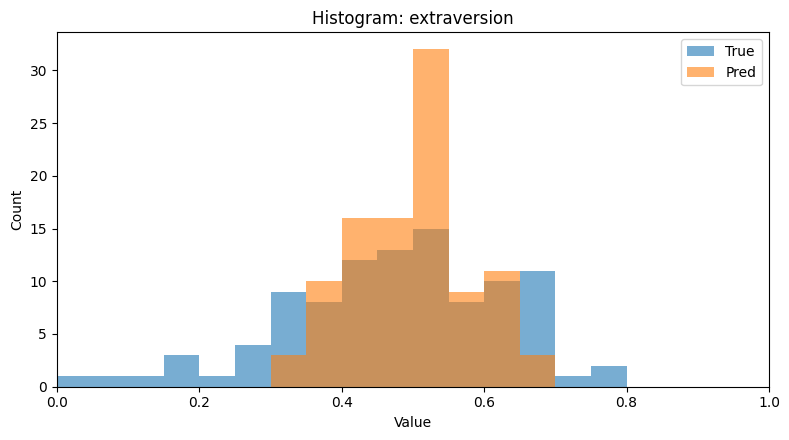

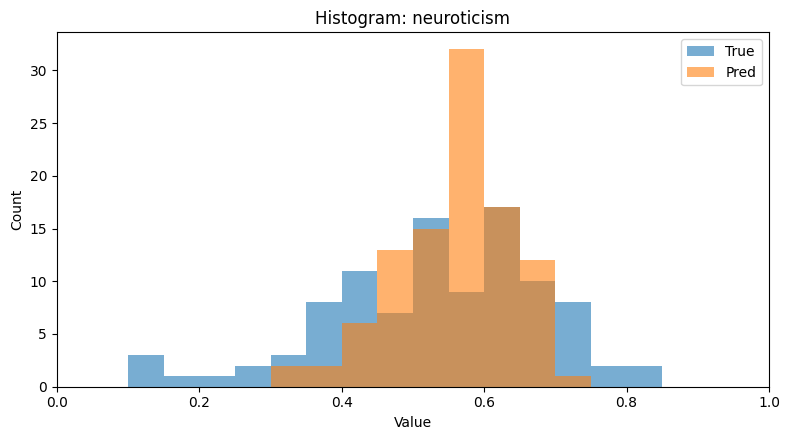

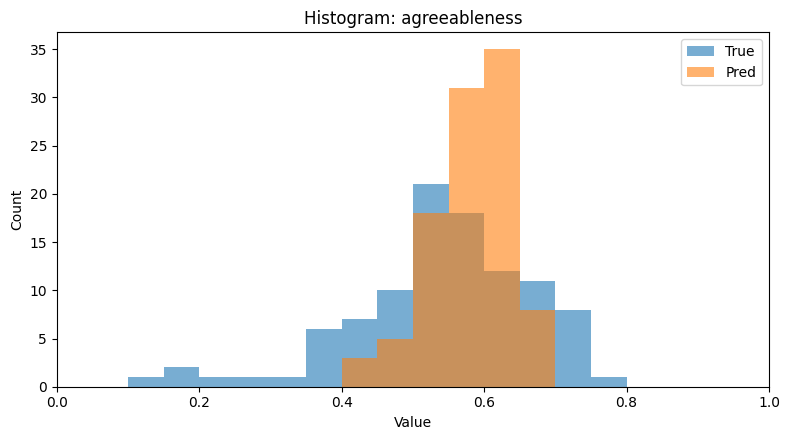

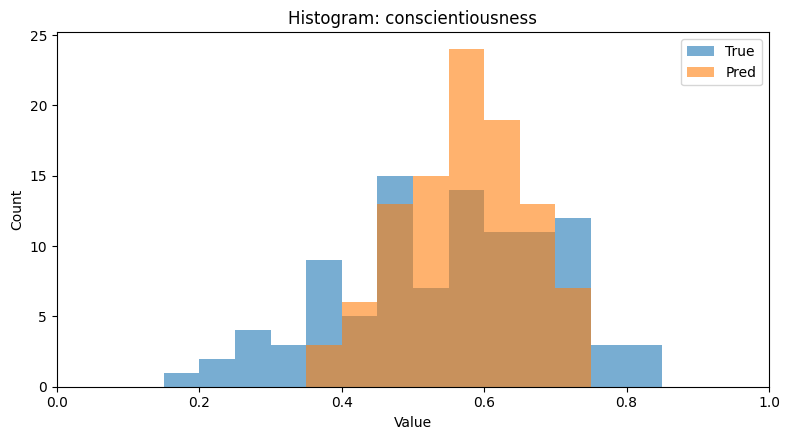

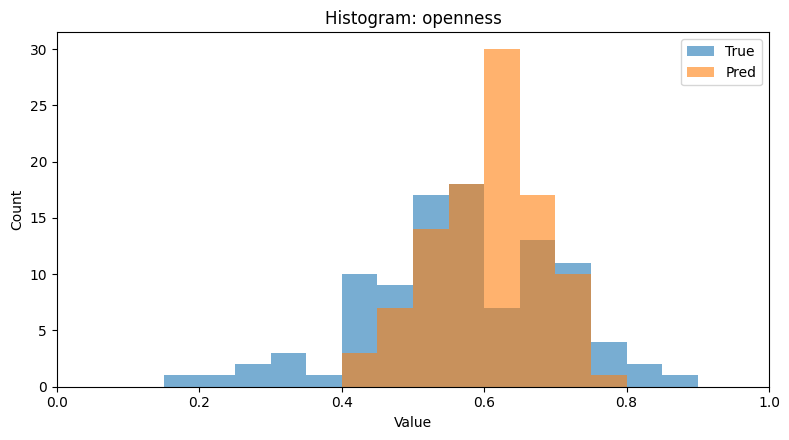

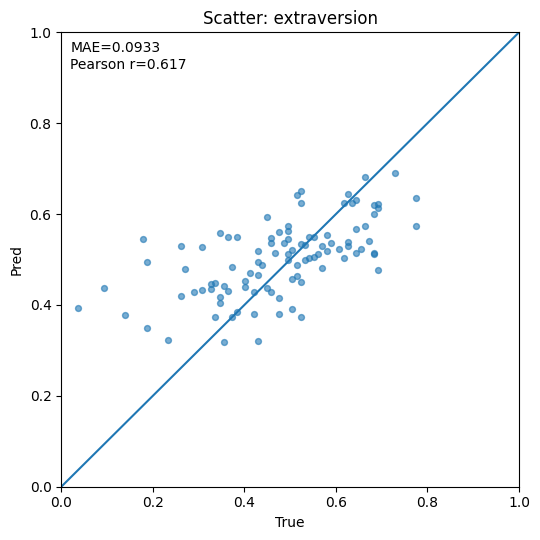

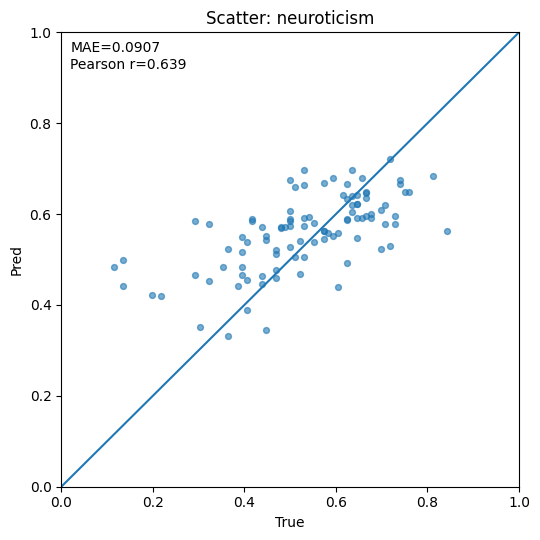

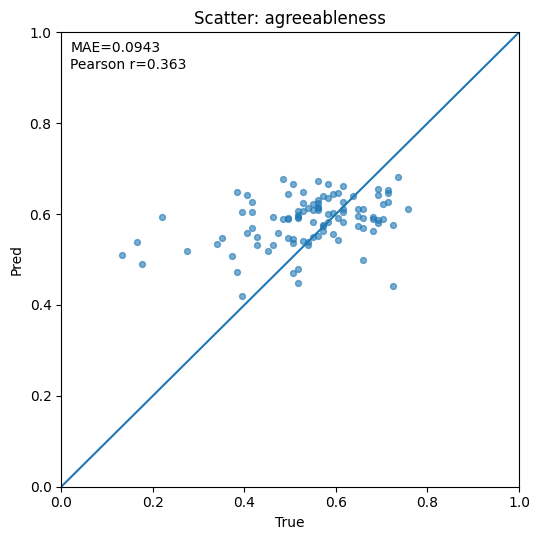

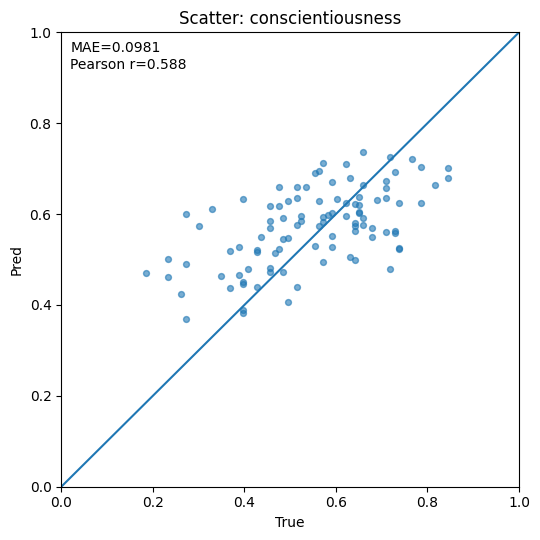

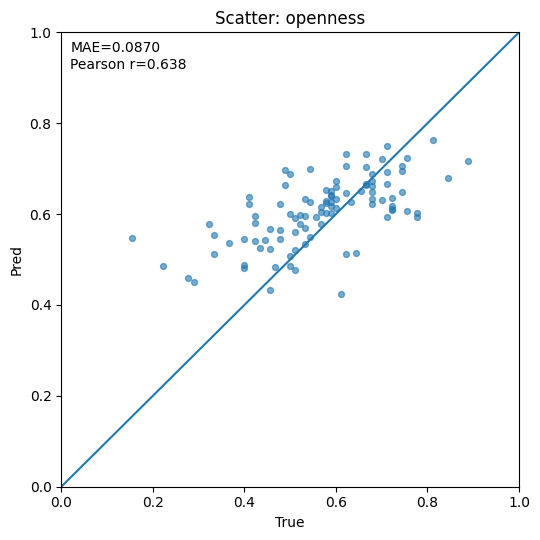

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Pastikan ini sudah ada:
# y_true: (N,5)
# y_pred: (N,5)
# LABEL_COLS = ["extraversion","neuroticism","agreeableness","conscientiousness","openness"]

def _pearsonr_np(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def plot_histograms(y_true, y_pred, labels, bins=20, clip=(0, 1)):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        plt.figure(figsize=(8, 4.5))
        plt.hist(yt, bins=bins, alpha=0.6, label="True", range=clip)
        plt.hist(yp, bins=bins, alpha=0.6, label="Pred", range=clip)
        plt.xlim(*clip)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title(f"Histogram: {name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

def plot_scatter(y_true, y_pred, labels, clip=(0, 1)):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        mae = float(np.mean(np.abs(yp - yt)))
        r = _pearsonr_np(yp, yt)

        plt.figure(figsize=(5.5, 5.5))
        plt.scatter(yt, yp, alpha=0.6, s=18)
        # garis y=x
        lo, hi = clip
        plt.plot([lo, hi], [lo, hi])

        plt.xlim(lo, hi)
        plt.ylim(lo, hi)
        plt.xlabel("True")
        plt.ylabel("Pred")
        plt.title(f"Scatter: {name}")
        plt.text(
            0.02, 0.98,
            f"MAE={mae:.4f}\nPearson r={r:.3f}",
            transform=plt.gca().transAxes,
            va="top"
        )
        plt.tight_layout()
        plt.show()

# ==== RUN PLOTS ====
plot_histograms(y_true, y_pred, LABEL_COLS, bins=20, clip=(0, 1))
plot_scatter(y_true, y_pred, LABEL_COLS, clip=(0, 1))
